# Example of Running HeST
We want to set the working directory to be HeST so that we can find the subdirectories HeST (I know there are two of them, it's odd). 

In [1]:
%cd ..
%pwd

/home/cveihmeyer_umass_edu/HeST


'/home/cveihmeyer_umass_edu/HeST'

In [2]:
import os
import HeST as hest
import numpy as np
import matplotlib.pyplot as plt
import HeST.Detection as detection
from analysis.analysis_functions import *

# import astropy.stats as astat
from scipy.interpolate import interp1d

## Setting up the Sim
We need to set all the parameters that we care about. 

1. Choose a detector setup to run. These currently live in HeST._detector-setup_ but I might change this in a bit. 
2. Compile that detector. Each detector is create by an object, which has attributes that corresponds to the mathematical definition. Please see review\_detector\_setup.py for a clear example of how the system is made. 
3. Define the parameters that you want. 
 The 'good' evaporation parameters are below

In [ ]:
import HeST.optimize_6_1 as examp

detector = examp.Amherst_split_cpd 



detector.set_QP_reflection_prob(0.15)
detector.set_diffuse_prob(0.95)
# detector.set_evaporation_eff([0.0,0.0,0.125,0.0,0.5,0.0])
detector.set_evaporation_eff([0.0,0.0,0.125,0.0,0.5,0.0,])


pos = [0.0, 0.0, 0.5]

useMap = False
# This is where the simulation is actually run, take a look through the d
evap = hest.GetEvaporationSignal( detector, 1000, *pos, useMap=useMap, debug=False,  plot_3d=False, choose_momentum=False, flavor_switching=True, verbose=False)


## Basic Analysis Tools
These are not great or highly developed, but they are somewhat useful to look at the data really quickly

<Figure size 640x480 with 0 Axes>

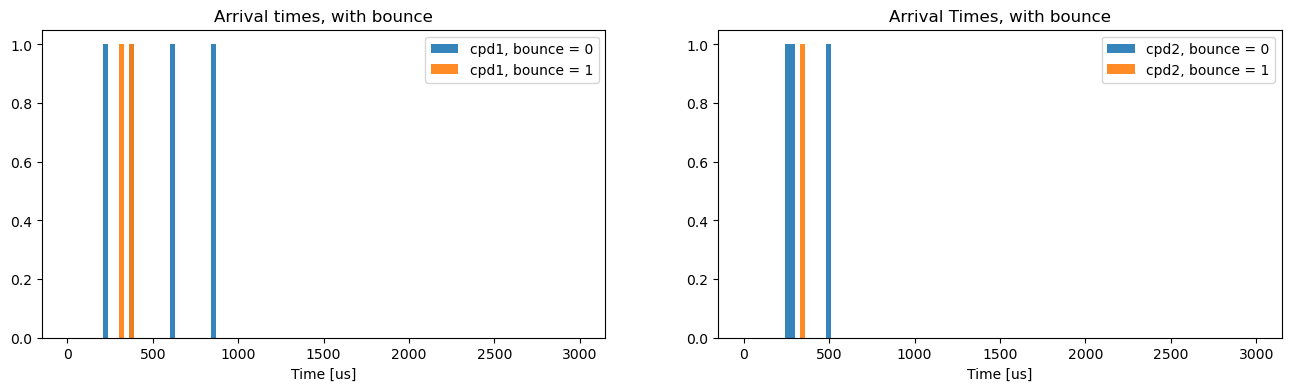

In [10]:
plot_stacked_hist(evap, bin_number=100)

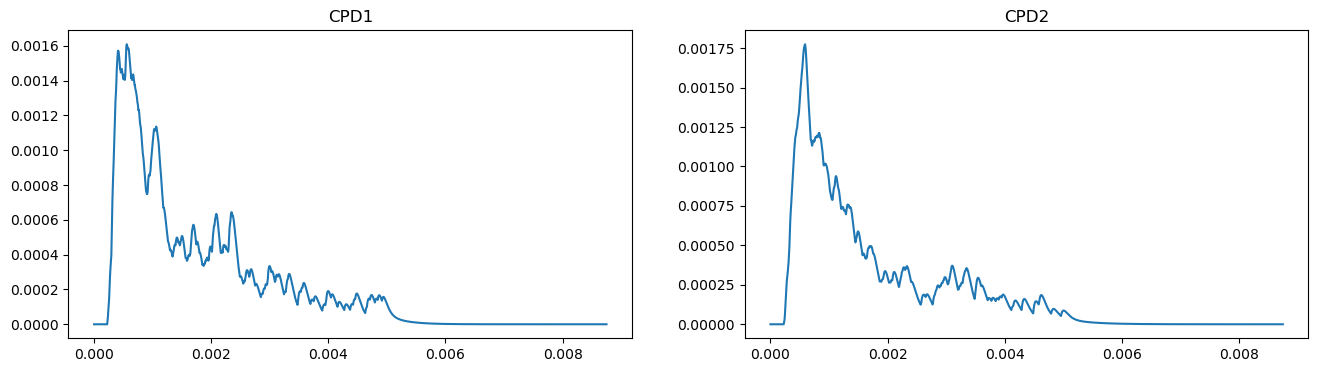

In [6]:
plot_waveform(evap)

and my personal favorite

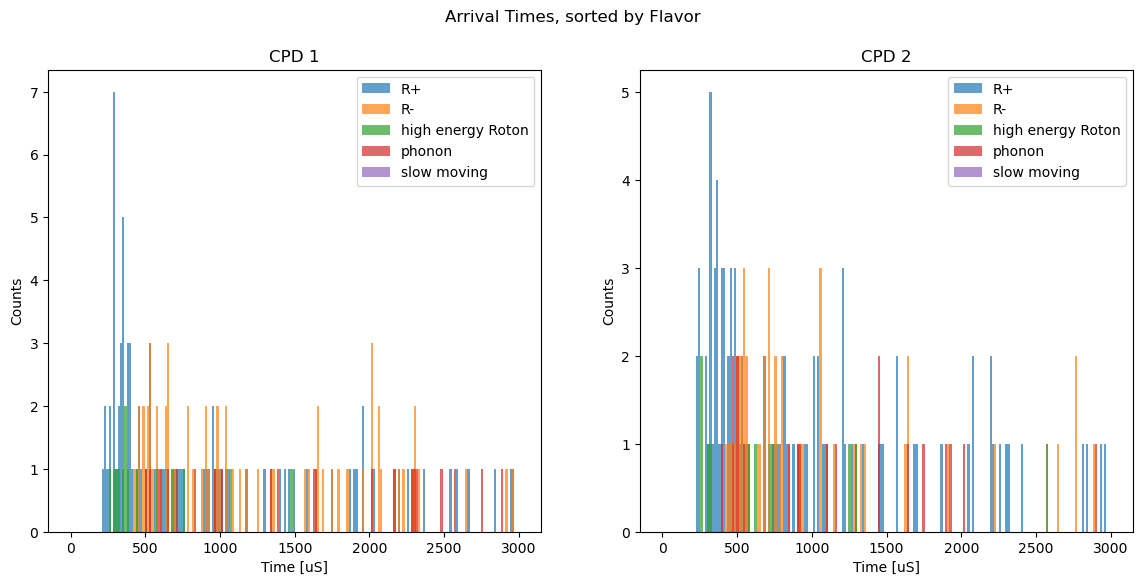

In [7]:
plot_hist_flavors(evap)

The statistics are just bad here, because I ran this with only 1000 QP's. With 1e6 Qp's this will look much better, much more continuous. 